# Linear Regression

**Goal:** Fit a straight line `ŷ = b0 + b1·x` to predict salary from experience.
The model minimises MSE (Mean Squared Error) to find the best slope and intercept.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### import Data

In [2]:
df = pd.read_csv("linear-regression-dataset.csv",sep=";")

In [3]:
df.head()

,experience,salary
0,0.5,2500
1,0.0,2250
2,1.0,2750
3,5.0,8000
4,8.0,9000


### plot data

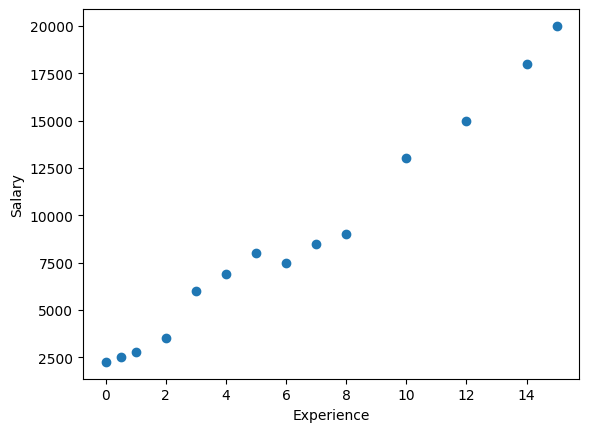

In [4]:
plt.scatter(df.experience,df.salary)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

### sklearn

scikit-learn's `LinearRegression` handles the least-squares calculation internally.
We reshape the 1-D series into a column vector `(-1, 1)` because sklearn expects a 2-D feature matrix.

In [5]:
df.experience.shape

(14,)

In [6]:
#sklearn doesnt understand like this shape (14,)
#we have to change the shape if we want to use sklearn

from sklearn.linear_model import LinearRegression

# linear regression model
linear_reg = LinearRegression()
x = df.experience.values.reshape(-1,1)
y = df.salary.values.reshape(-1,1)
linear_reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
x.shape

(14, 1)

### prediction 

In [8]:
b0 = linear_reg.predict([[0]])
print("b0: ",b0)

b0:  [[1663.89519747]]


In [9]:
# we can find the same result with different way 
b0_ = linear_reg.intercept_ # the point that intersects y-axis
print("b0_: ",b0_)

b0_:  [1663.89519747]


In [10]:
b1 = linear_reg.coef_ # slope
print("b1: ",b1) # Linear Regression formula: y = b0 + b1 * x

b1:  [[1138.34819698]]


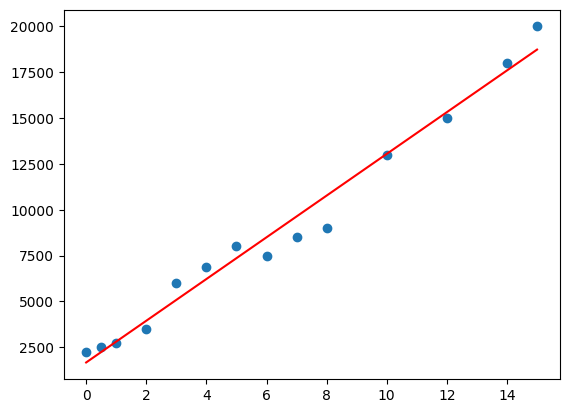

In [11]:
array = np.array([i for i in range(0,16)]).reshape(-1,1)
plt.scatter(x,y)
y_head = linear_reg.predict(array)
plt.plot(array,y_head,color="red")
plt.show()

In [12]:
linear_reg.predict([[100]]) # example: a man who has 100 years experience earns 115K dolar

array([[115498.71489503]])